# Extract Lake water extent using a dataset from GEE

In [ ]:
import ee 
import pandas as pd
import time
from pathlib import Path
from src.lakeclimate import jrc

import matplotlib.dates as mdates
import datetime as dt
import matplotlib.pyplot as plt 

ee.Authenticate()  # only needed once, then it remembers
ee.Initialize(project="lake-poopo-climate-2026")
path_root = Path.cwd()
# path to the extracted .csv water extent data
data_jrc_path = path_root / "data_jrc"

We define the geographic area in which the Poopó lake and immediate sorrounding are contained. We also specify the dataset that will be used to extract the water surface extent: https://developers.google.com/earth-engine/datasets/catalog/JRC_GSW1_4_MonthlyHistory. 

In [4]:
# Coordinates for the bounds of a rectagle in which the Lake is contained.
# Google earth engine uses the format: (min_lon, min_lat, max_lon, max_lat) i.e. (West, South, East, North)
poopo_area = [-67.50, -19.20, -66.60,-18.30]
# Defines a rectangular geographic area within Earth engine
poopo_geom = ee.Geometry.Rectangle(list(poopo_area))

# This is a static dataset
# ID of the dataset containing maps of the location and temporal distribution of surface water from 1984 to 2021 in Google Earth Engine
jrc_monthly = "JRC/GSW1_4/MonthlyHistory"


In [5]:
lwe_jrc_path = data_jrc_path / "processed" / "Poopo_lwe_jrc_1985-2022.csv"

if lwe_jrc_path.exists():
    jrc_df = pd.read_csv(lwe_jrc_path, parse_dates=["date"])
    print(f"Loaded {len(jrc_df)} cached observations from {lwe_jrc_path}")
else:
    jrc_df = jrc.monthly_water_area_km2("1985-01-01", "2022-12-31")
    jrc_df.to_csv(lwe_jrc_path, index=False)
    print(f"Saved {len(jrc_df)} observations to {lwe_jrc_path}")

print(jrc_df.head())

Loaded 454 cached observations from /Users/nayualv/Desktop/Github_projects/Urus_project/Lake_Poopo/data_jrc/processed/Poopo_lwe_jrc_1985-2022.csv
        date  valid_area_km2  water_area_km2
0 1984-03-01        0.000000             0.0
1 1984-04-01        0.000000             0.0
2 1984-05-01        0.000000             0.0
3 1984-06-01       11.143252             0.0
4 1984-07-01        0.000000             0.0


# Lake water extent

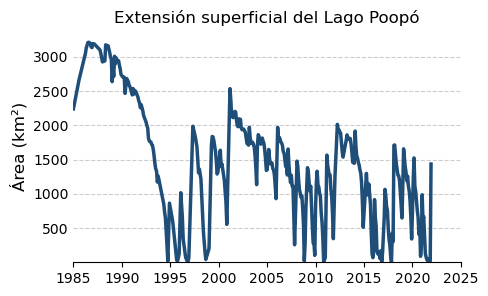

In [10]:

path_root = Path.cwd()

jrc_df = pd.read_csv(lwe_jrc_path)
jrc_df["date"] = pd.to_datetime(jrc_df["date"])

total_area_km2 = jrc_df["valid_area_km2"].max()
#The percentage of the image box that has been observed
jrc_df["coverage"] = jrc_df["valid_area_km2"] / total_area_km2 * 100
# I require at least 80% 
clean_df = jrc_df[jrc_df["coverage"]>= 80].copy()

fig, ax1 = plt.subplots(figsize=(5, 3))

ax1.plot(clean_df['date'], clean_df["water_area_km2"],linewidth =2.5, color="#1f4e79")
ax1.set_ylabel(f"Área (km²)", fontsize=12)
ax1.set_xlim(dt.datetime(1985, 1, 1),dt.datetime(2025, 1, 1) )
ax1.xaxis.set_major_locator(mdates.YearLocator(base=5))
#ax1.xaxis.set_minor_locator(mdates.YearLocator(base=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.tick_params(axis='both', labelsize=10)
ax1.tick_params(axis='y', length=0)
ax1.set_yticks([500, 1000, 1500, 2000,2500,3000])
ax1.set_ylim(bottom=0)

ax1.grid(
    axis='y',
    linestyle='--',     
    linewidth=0.8,
    color='gray',
    alpha=0.4
)

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_alpha(0)
ax1.spines['bottom'].set_alpha(1)

ax1.set_title("Extensión superficial del Lago Poopó")
path_to_save = path_root / "figures" / "Poopo_lwe_1984-2021.png"
plt.savefig(path_to_save, transparent = True)
plt.show()